# SW and W Distance Data from Result Excel

In [1]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# ===================== Core Config =====================
dataset_name = "market"
data_dir = f"./{dataset_name}"

file_config_list = [
    {
        "short_name": "DCE",  
        "name": "Raw_DCE",
        "filename_suffix": "_DCE.xlsx",
        "sheet_name": "DCE_Metrics_Summary",
        "sw_col": "X_SWD",
        "w_col": "Y_WD"
    },
    {
        "short_name": "Mean",  
        "name": "Mean_Constrained",
        "filename_suffix": "_MeanConstraint.xlsx",
        "sheet_name": "Mean_Metrics_Summary",
        "sw_col": "X_SWD_mean",
        "w_col": "Y_WD_mean"
    },
    {
        "short_name": "Std",  
        "name": "Std_Constrained",
        "filename_suffix": "_StdConstraint.xlsx",
        "sheet_name": "Std_Metrics_Summary",
        "sw_col": "X_SWD_std",
        "w_col": "Y_WD_std"
    },
    {
        "short_name": "LSC",  
        "name": "LSC_Constrained",
        "filename_suffix": "_LSCConstraint.xlsx",
        "sheet_name": "LSC_Metrics_Summary",
        "sw_col": "X_SWD_lsc",
        "w_col": "Y_WD_lsc"
    },
    {
        "short_name": "FSD", 
        "name": "FSD_Constrained",
        "filename_suffix": "_FSDConstraint_NumDealsPurchases_0.004.xlsx",
        "sheet_name": "FSD_Metrics_Summary",
        "sw_col": "X_SWD_fsd",
        "w_col": "Y_WD_fsd"
    }
]

sww_stats = {}
for config in file_config_list:
    file_path = os.path.join(data_dir, dataset_name + config["filename_suffix"])
    df = pd.read_excel(file_path, sheet_name=config["sheet_name"], engine="openpyxl")
    
    sw_mean = df[config["sw_col"]].mean()
    sw_std = df[config["sw_col"]].std()
    w_mean = df[config["w_col"]].mean()
    w_std = df[config["w_col"]].std()
    
    sww_stats[config["short_name"]] = {
        "SW_Mean": round(sw_mean, 6),
        "SW_Std": round(sw_std, 6),
        "W_Mean": round(w_mean, 6),
        "W_Std": round(w_std, 6)
    }

sww_stats_df = pd.DataFrame(sww_stats).T
print("=== SW/W Mean & Std Results ===")
print(sww_stats_df)

=== SW/W Mean & Std Results ===
       SW_Mean    SW_Std    W_Mean     W_Std
DCE   0.156713  0.019405  0.074616  0.001191
Mean  0.147038  0.029840  0.071602  0.002331
Std   0.153055  0.020204  0.072517  0.003565
LSC   0.155166  0.015619  0.067851  0.004048
FSD   0.155668  0.017598  0.071089  0.002899


In [2]:
plot_rows = []

for config in file_config_list:
    file_path = os.path.join(data_dir, dataset_name + config["filename_suffix"])
    df = pd.read_excel(file_path, sheet_name=config["sheet_name"], engine="openpyxl")

    sw_vals = df[config["sw_col"]].dropna().reset_index(drop=True)
    w_vals = df[config["w_col"]].dropna().reset_index(drop=True)

    n = min(len(sw_vals), len(w_vals))

    for i in range(n):
        plot_rows.append({
            "constraint": config["short_name"],
            "run": i + 1,
            "SWD": sw_vals.iloc[i],
            "WD": w_vals.iloc[i]
        })

plot_df = pd.DataFrame(plot_rows)

print("=== Plot-ready data ===")
print(plot_df)

=== Plot-ready data ===
   constraint  run       SWD        WD
0         DCE    1  0.180725  0.075220
1         DCE    2  0.146664  0.075340
2         DCE    3  0.170027  0.075826
3         DCE    4  0.131257  0.073121
4         DCE    5  0.154892  0.073575
5        Mean    1  0.177806  0.073694
6        Mean    2  0.138459  0.073958
7        Mean    3  0.166641  0.068592
8        Mean    4  0.100805  0.069955
9        Mean    5  0.151481  0.071809
10        Std    1  0.176620  0.071990
11        Std    2  0.139255  0.066767
12        Std    3  0.165068  0.074553
13        Std    4  0.126265  0.073161
14        Std    5  0.158067  0.076114
15        LSC    1  0.159544  0.064509
16        LSC    2  0.142593  0.072535
17        LSC    3  0.169510  0.065612
18        LSC    4  0.135152  0.071975
19        LSC    5  0.169032  0.064625
20        FSD    1  0.163763  0.067657
21        FSD    2  0.143928  0.070787
22        FSD    3  0.176201  0.072568
23        FSD    4  0.131875  0.075132
2

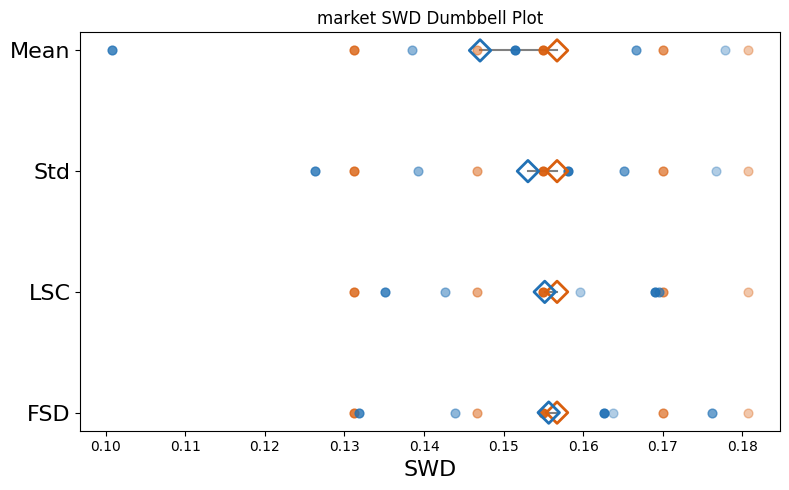

In [3]:
import matplotlib.pyplot as plt
import numpy as np

metric = "SWD"  

constraints = ["Mean", "Std", "LSC", "FSD"]
y_pos = np.arange(len(constraints))

baseline_vals = plot_df[plot_df["constraint"] == "DCE"][metric].values
baseline_mean = baseline_vals.mean()

baseline_color = "#d95f0e"
constrained_color = "#2171b5"
alphas = [0.35, 0.5, 0.65, 0.8, 0.95]

fig, ax = plt.subplots(figsize=(8, 5))

for i, c in enumerate(constraints):
    constrained_vals = plot_df[plot_df["constraint"] == c][metric].values
    constrained_mean = constrained_vals.mean()

    # baseline 5
    for j, val in enumerate(baseline_vals):
        ax.scatter(
            val,
            i,
            color=baseline_color,
            alpha=alphas[j],
            s=40,
            zorder=3
        )

    # constrained 5
    for j, val in enumerate(constrained_vals):
        ax.scatter(
            val,
            i,
            color=constrained_color,
            alpha=alphas[j],
            s=40,
            zorder=3
        )

    ax.plot(
        [baseline_mean, constrained_mean],
        [i, i],
        color="gray",
        linewidth=1.5,
        zorder=2
    )

    ax.scatter(
        baseline_mean, i,
        facecolors="none",
        edgecolors=baseline_color,
        s=120, marker="D", linewidths=2, zorder=5
    )
    ax.scatter(
        constrained_mean, i,
        facecolors="none",
        edgecolors=constrained_color,
        s=120, marker="D", linewidths=2, zorder=5
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(constraints,fontsize=16)
ax.invert_yaxis()

ax.set_xlabel(metric,fontsize=16)
# ax.set_ylabel("Constraint")
ax.set_title(f"{dataset_name} {metric} Dumbbell Plot")

plt.tight_layout()
plt.show()

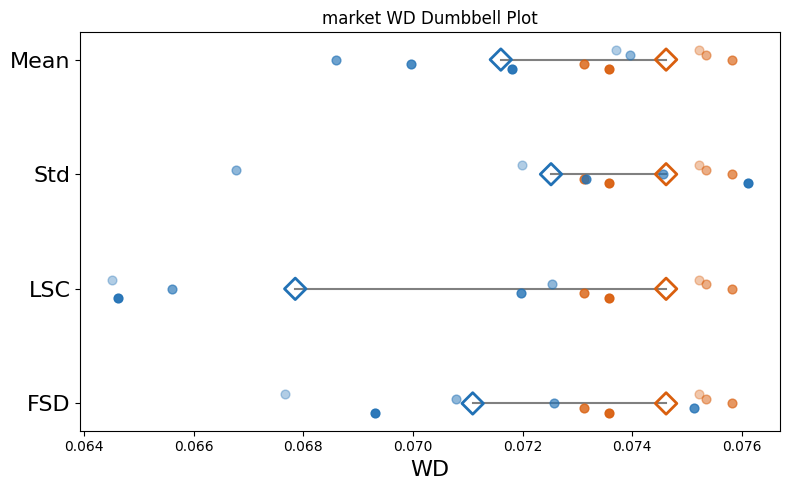

In [4]:
import matplotlib.pyplot as plt
import numpy as np

metric = "WD"   

constraints = ["Mean", "Std", "LSC", "FSD"]
y_pos = np.arange(len(constraints))

baseline_vals = plot_df[plot_df["constraint"] == "DCE"][metric].values
baseline_mean = baseline_vals.mean()

baseline_color = "#d95f0e"
constrained_color = "#2171b5"
alphas = [0.35, 0.5, 0.65, 0.8, 0.95]

fig, ax = plt.subplots(figsize=(8, 5))

for i, c in enumerate(constraints):
    constrained_vals = plot_df[plot_df["constraint"] == c][metric].values
    constrained_mean = constrained_vals.mean()

    offsets = np.array([-0.08, -0.04, 0.0, 0.04, 0.08])
    for j, val in enumerate(baseline_vals):
        ax.scatter(
            val,
            i + offsets[j],
            color=baseline_color,
            alpha=alphas[j],
            s=40,
            zorder=3
        )

    for j, val in enumerate(constrained_vals):
        ax.scatter(
            val,
            i + offsets[j],
            color=constrained_color,
            alpha=alphas[j],
            s=40,
            zorder=3
        )

    ax.plot(
        [baseline_mean, constrained_mean],
        [i, i],
        color="gray",
        linewidth=1.5,
        zorder=2
    )

    ax.scatter(
        baseline_mean, i,
        facecolors="none",
        edgecolors=baseline_color,
        s=120, marker="D", linewidths=2, zorder=5
    )
    ax.scatter(
        constrained_mean, i,
        facecolors="none",
        edgecolors=constrained_color,
        s=120, marker="D", linewidths=2, zorder=5
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(constraints,fontsize=16)
ax.invert_yaxis()   

ax.set_xlabel(metric,fontsize=16)
# ax.set_ylabel("Constraint",fontsize=16)
ax.set_title(f"{dataset_name} {metric} Dumbbell Plot")

plt.tight_layout()
plt.show()

# mean

In [5]:
file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    Recency_col = next(col for col in df.columns if "Recency" in col)
    Recency_mean = round(df[Recency_col].mean(), 6)
    result_list.append([sheet, Recency_mean])

print("=== Result DataFrame ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "Recency_Mean"])
print(result_df)

overall_mean = round(result_df["Recency_Mean"].mean(), 6)
overall_std = round(result_df["Recency_Mean"].std(), 6)
print("\n=== Overall Statistics ===")
print(f"Mean of 5 Recency Means: {overall_mean}")
print(f"Std of 5 Recency Means: {overall_std}")

=== Result DataFrame ===
    Sheet_Name  Recency_Mean
0  DCE_Seed_40     47.361163
1  DCE_Seed_41     47.571314
2  DCE_Seed_42     47.999176
3  DCE_Seed_43     48.443040
4  DCE_Seed_44     47.926802

=== Overall Statistics ===
Mean of 5 Recency Means: 47.860299
Std of 5 Recency Means: 0.417117


In [6]:
baseline_means = result_df["Recency_Mean"].tolist()
baseline_overall_mean = overall_mean

In [7]:
file_path = os.path.join(data_dir, f"{dataset_name}_MeanConstraint.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    Recency_col = next(col for col in df.columns if "Recency" in col)
    Recency_mean = round(df[Recency_col].mean(), 6)
    result_list.append([sheet, Recency_mean])

print("=== Result DataFrame ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "Recency_Mean"])
print(result_df)

overall_mean = round(result_df["Recency_Mean"].mean(), 6)
overall_std = round(result_df["Recency_Mean"].std(), 6)
print("\n=== Overall Statistics ===")
print(f"Mean of 5 Recency Means: {overall_mean}")
print(f"Std of 5 Recency Means: {overall_std}")

=== Result DataFrame ===
     Sheet_Name  Recency_Mean
0  Mean_Seed_40     53.962625
1  Mean_Seed_41     53.962604
2  Mean_Seed_42     53.935516
3  Mean_Seed_43     53.890625
4  Mean_Seed_44     53.924802

=== Overall Statistics ===
Mean of 5 Recency Means: 53.935234
Std of 5 Recency Means: 0.029993


In [8]:
meanconstraint_means = result_df["Recency_Mean"].tolist()
meanconstraint_overall_mean = overall_mean

[47.361163, 47.571314, 47.999176, 48.44304, 47.926802]
[53.962625, 53.962604, 53.935516, 53.890625, 53.924802]
53.9352344


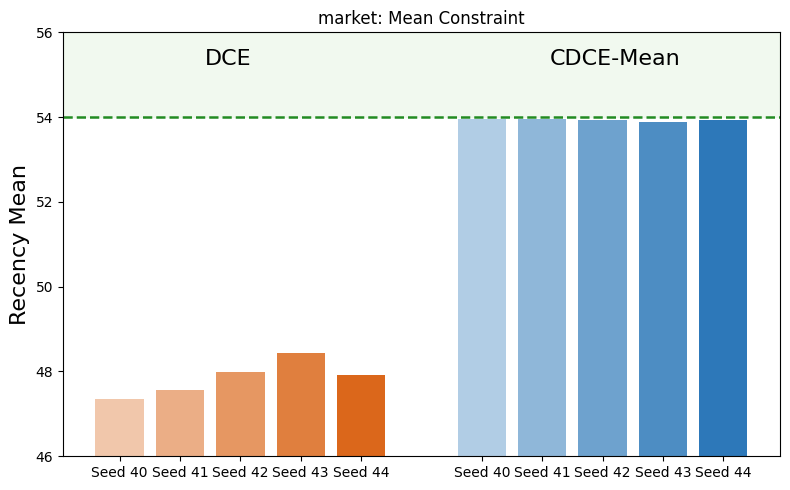

In [9]:
print(baseline_means)
print(meanconstraint_means)
t = np.mean(meanconstraint_means)
print(t)

x_base = np.arange(5)
x_cons = np.arange(5) + 6

fig, ax = plt.subplots(figsize=(8, 5))

for i, val in enumerate(baseline_means):
    ax.bar(x_base[i], val, color=baseline_color, alpha=alphas[i], width=0.8)

for i, val in enumerate(meanconstraint_means):
    ax.bar(x_cons[i], val, color=constrained_color, alpha=alphas[i], width=0.8)

target_lower = 54
ax.axhspan(target_lower, 56, color="#d9f0d3", alpha=0.35, zorder=0)
ax.axhline(target_lower, color="forestgreen", linestyle="--", linewidth=1.8)

ax.set_xticks(list(x_base) + list(x_cons))
ax.set_xticklabels(
    ["Seed 40", "Seed 41", "Seed 42", "Seed 43", "Seed 44",
     "Seed 40", "Seed 41", "Seed 42", "Seed 43", "Seed 44"],
    rotation=0
)

ax.set_ylim(46, 56)
ax.set_yticks(np.arange(46, 57, 2))

# ax.text(np.mean(x_base), 55.6, "DCE", ha="center", va="top")
# ax.text(np.mean(x_cons), 55.6, "Mean-Constrained", ha="center", va="top")

ax.text(
    0.23, 0.96, "DCE",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=16
)

ax.text(
    0.77, 0.96, "CDCE-Mean",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=16
)

ax.set_ylabel("Recency Mean",fontsize=16)
ax.set_title(f"{dataset_name}: Mean Constraint")
plt.tight_layout()
plt.show()

# std

=== Result DataFrame (Sheet Name & Income Std) ===
    Sheet_Name    Income_Std
0  DCE_Seed_40  20321.784381
1  DCE_Seed_41  20407.315569
2  DCE_Seed_42  20218.530759
3  DCE_Seed_43  20160.724646
4  DCE_Seed_44  20421.628474

=== Overall Statistics of Income Stds ===
Mean of 5 Income Stds: 20305.996766
Std of 5 Income Stds: 114.716751
=== Result DataFrame (Sheet Name & Income Std) ===
    Sheet_Name    Income_Std
0  Std_Seed_40  19076.641573
1  Std_Seed_41  19097.537758
2  Std_Seed_42  19009.131482
3  Std_Seed_43  19062.204263
4  Std_Seed_44  19089.714112

=== Overall Statistics of Income Stds ===
Mean of 5 Income Stds: 19067.045838
Std of 5 Income Stds: 35.047109
[20321.784381, 20407.315569, 20218.530759, 20160.724646, 20421.628474]
[19076.641573, 19097.537758, 19009.131482, 19062.204263, 19089.714112]


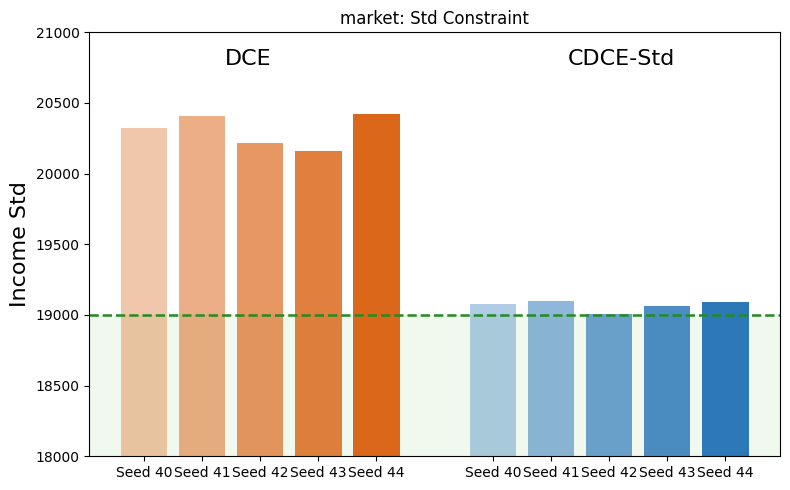

In [10]:
file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    Income_col = next(col for col in df.columns if "Income" in col)
    Income_std = round(df[Income_col].dropna().std(), 6)
    result_list.append([sheet, Income_std])

print("=== Result DataFrame (Sheet Name & Income Std) ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "Income_Std"])
print(result_df)

Income_std_mean = round(result_df["Income_Std"].mean(), 6)
Income_std_self_std = round(result_df["Income_Std"].std(), 6)

print("\n=== Overall Statistics of Income Stds ===")
print(f"Mean of 5 Income Stds: {Income_std_mean}")
print(f"Std of 5 Income Stds: {Income_std_self_std}")

baseline_stds = result_df["Income_Std"].tolist()
baseline_std_mean = Income_std_mean

file_path = os.path.join(data_dir, f"{dataset_name}_StdConstraint.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    Income_col = next(col for col in df.columns if "Income" in col)
    Income_std = round(df[Income_col].dropna().std(), 6)
    result_list.append([sheet, Income_std])

print("=== Result DataFrame (Sheet Name & Income Std) ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "Income_Std"])
print(result_df)

Income_std_mean = round(result_df["Income_Std"].mean(), 6)
Income_std_self_std = round(result_df["Income_Std"].std(), 6)

print("\n=== Overall Statistics of Income Stds ===")
print(f"Mean of 5 Income Stds: {Income_std_mean}")
print(f"Std of 5 Income Stds: {Income_std_self_std}")

stdconstraint_stds = result_df["Income_Std"].tolist()
stdconstraint_std_mean = Income_std_mean

print(baseline_stds)
print(stdconstraint_stds)

x_base = np.arange(5)
x_cons = np.arange(5) + 6

fig, ax = plt.subplots(figsize=(8, 5))

for i, val in enumerate(baseline_stds):
    ax.bar(x_base[i], val, color=baseline_color, alpha=alphas[i], width=0.8)

for i, val in enumerate(stdconstraint_stds):
    ax.bar(x_cons[i], val, color=constrained_color, alpha=alphas[i], width=0.8)

target_upper = 19000
ax.axhspan(0, target_upper, color="#d9f0d3", alpha=0.35, zorder=0)
ax.axhline(target_upper, color="forestgreen", linestyle="--", linewidth=1.8)

ax.set_xticks(list(x_base) + list(x_cons))
ax.set_xticklabels(
    ["Seed 40", "Seed 41", "Seed 42", "Seed 43", "Seed 44",
     "Seed 40", "Seed 41", "Seed 42", "Seed 43", "Seed 44"],
    rotation=0
)

y_max = max(max(baseline_stds), max(stdconstraint_stds))
# ax.set_ylim(min(9.2, min(min(baseline_stds), min(stdconstraint_stds)) - 0.2), y_max + 0.4)
ax.set_ylim(18000, 21000)

ax.text(
    0.23, 0.96, "DCE",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=16
)

ax.text(
    0.77, 0.96, "CDCE-Std",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=16
)

ax.set_ylabel("Income Std",fontsize=16)
ax.set_title(f"{dataset_name}: Std Constraint")
plt.tight_layout()
plt.show()

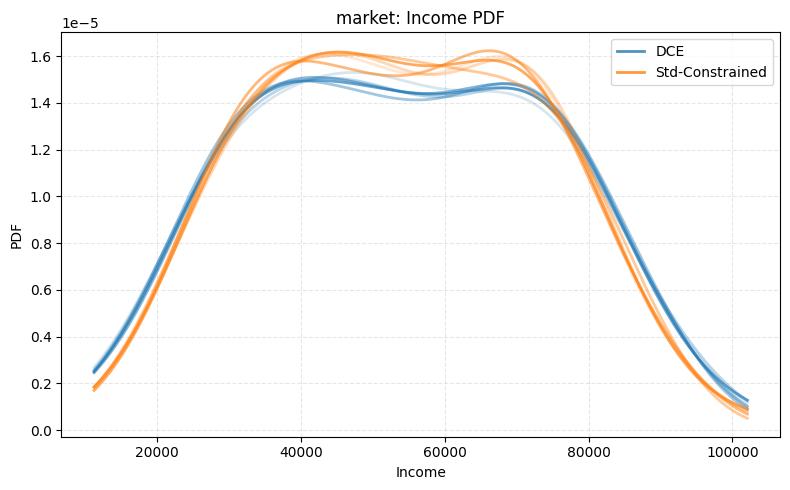

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Use the same default matplotlib colors
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
baseline_color = default_colors[0]
constrained_color = default_colors[1]
alphas = [0.18, 0.30, 0.42, 0.54, 0.66]

# Read 5 runs from DCE
file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")
xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

baseline_data = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    Income_col = next(col for col in df.columns if "Income" in col)
    baseline_data.append(df[Income_col].dropna().values)

# Read 5 runs from StdConstraint
file_path = os.path.join(data_dir, f"{dataset_name}_StdConstraint.xlsx")
xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

constrained_data = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    Income_col = next(col for col in df.columns if "Income" in col)
    constrained_data.append(df[Income_col].dropna().values)

# Shared x range
all_values = np.concatenate(baseline_data + constrained_data)
x_grid = np.linspace(all_values.min(), all_values.max(), 500)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

for i, values in enumerate(baseline_data):
    kde = gaussian_kde(values)
    y = kde(x_grid)
    ax.plot(x_grid, y, color=baseline_color, alpha=alphas[i], linewidth=2)

for i, values in enumerate(constrained_data):
    kde = gaussian_kde(values)
    y = kde(x_grid)
    ax.plot(x_grid, y, color=constrained_color, alpha=alphas[i], linewidth=2)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=baseline_color, lw=2, alpha=0.8, label="DCE"),
    Line2D([0], [0], color=constrained_color, lw=2, alpha=0.8, label="Std-Constrained"),
]
ax.legend(handles=legend_elements)

ax.set_xlabel("Income")
ax.set_ylabel("PDF")
ax.set_title(f"{dataset_name}: Income PDF")
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# lsc

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import os, random, numpy as np, torch
from sklearn.preprocessing import LabelEncoder

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)          
    np.random.seed(seed)       
    torch.manual_seed(seed)  
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed=42

target_name = "Response"  

seed = 42
set_seed(seed)
df = pd.read_excel('data/Marketing Campaign/marketing_campaign.xlsx')
df = df.drop(columns=['Z_CostContact', 'Z_Revenue'])

label_encoder = LabelEncoder()
label_mappings = {}

education_mapping = {
    'PhD': 3,
    'Master': 2,
    '2n Cycle': 2,
    'Graduation': 1,
    'Basic': 0
}
marital_mapping = {
    'Married': 1,
    'Together': 1,
    'Single': 0,
    'Divorced': 0,
    'Alone': 0,
    'YOLO': 0,
    'Absurd': 0
}

for column in df.columns:
    if column != target_name and df[column].dtype == 'object':  
        if column == "Education":
            df[column] = df[column].map(education_mapping)  
        elif column == "Marital_Status":
            df[column] = df[column].map(marital_mapping)  
        else:
            df[column] = label_encoder.fit_transform(df[column].astype(str))

for column in df.columns:
    if df[column].isna().any():
        median_val = df[column].median()
        df[column] = df[column].fillna(median_val).astype(int)

df_X = df.iloc[:, 1:].copy()
df_X = df_X.drop(columns=['Response'])
df_y = df[target_name]


set_seed(seed)
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.2, random_state=seed)

std = X_train.std()
mean = X_train.mean()

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print(X_train)

X_lin_train = X_train[["MntSweetProducts"]].values.reshape(-1, 1)
y_lin_train = X_train["MntFruits"].values

lin_reg = LinearRegression()
lin_reg.fit(X_lin_train, y_lin_train)

y_pred_train = lin_reg.predict(X_lin_train)
mse_train = mean_squared_error(y_lin_train, y_pred_train)

coef = lin_reg.coef_[0]
intercept = lin_reg.intercept_
print(f"Linear model: MntFruits = {coef:.4f} * MntSweetProducts + {intercept:.4f}")
print(f"MSE on training data: {mse_train:.4f}")

      Year_Birth  Education  Marital_Status    Income   Kidhome  Teenhome  \
792    -1.596179  -0.784853       -1.475158 -1.350995 -0.837688 -0.925309   
1271   -0.501484   0.402030       -1.475158  0.470273 -0.837688  0.912999   
1538    0.172174   1.588913        0.677515  0.769269 -0.837688  0.912999   
668    -0.080448   1.588913        0.677515 -0.875324  0.999688 -0.925309   
1975    0.003759  -0.784853        0.677515 -1.827090 -0.837688  0.912999   
...          ...        ...             ...       ...       ...       ...   
1638    0.003759  -0.784853        0.677515 -0.302895  0.999688  0.912999   
1095    0.845832  -0.784853       -1.475158  0.379321 -0.837688  0.912999   
1130   -1.511972   0.402030        0.677515  0.592900 -0.837688  0.912999   
1294   -0.501484   1.588913       -1.475158 -0.116840  0.999688  0.912999   
860     0.003759  -0.784853        0.677515 -1.104395  0.999688 -0.925309   

      Dt_Customer   Recency  MntWines  MntFruits  ...  NumWebPurchases  \
7

In [2]:
import pandas as pd
import numpy as np
import os, random, torch

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed = 42
set_seed(seed)

target_name = "Response"

# =========================
# 1. read data
# =========================
df = pd.read_excel("data/Marketing Campaign/marketing_campaign.xlsx")
df = df.drop(columns=["Z_CostContact", "Z_Revenue"])

# =========================
# 2. encode categorical columns
# =========================
label_encoder = LabelEncoder()

education_mapping = {
    "PhD": 3,
    "Master": 2,
    "2n Cycle": 2,
    "Graduation": 1,
    "Basic": 0
}

marital_mapping = {
    "Married": 1,
    "Together": 1,
    "Single": 0,
    "Divorced": 0,
    "Alone": 0,
    "YOLO": 0,
    "Absurd": 0
}

for column in df.columns:
    if column != target_name and df[column].dtype == "object":
        if column == "Education":
            df[column] = df[column].map(education_mapping)
        elif column == "Marital_Status":
            df[column] = df[column].map(marital_mapping)
        else:
            df[column] = label_encoder.fit_transform(df[column].astype(str))

# =========================
# 3. fill missing values
# =========================
for column in df.columns:
    if df[column].isna().any():
        median_val = df[column].median()
        df[column] = df[column].fillna(median_val)

# =========================
# 4. keep only input features
# =========================
df_X = df.iloc[:, 1:].copy()
df_X = df_X.drop(columns=[target_name]).copy()
df_y = df[target_name]

# =========================
# 5. split + normalize
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    df_X, df_y, test_size=0.2, random_state=seed
)

mean = X_train.mean()
std = X_train.std().replace(0, 1)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# =========================
# 6. pairwise linear regression
# =========================
results = []
features = X_train.columns.tolist()

for x_col in features:
    for y_col in features:
        if x_col == y_col:
            continue

        X_lin_train = X_train[[x_col]].values.reshape(-1, 1)
        y_lin_train = X_train[y_col].values

        lin_reg = LinearRegression()
        lin_reg.fit(X_lin_train, y_lin_train)

        y_pred_train = lin_reg.predict(X_lin_train)

        coef = lin_reg.coef_[0]
        intercept = lin_reg.intercept_
        mse_train = mean_squared_error(y_lin_train, y_pred_train)
        r2_train = r2_score(y_lin_train, y_pred_train)

        results.append({
            "X_feature": x_col,
            "Y_feature": y_col,
            "coef": coef,
            "intercept": intercept,
            "MSE": mse_train,
            "R2": r2_train
        })

# =========================
# 7. ranking table
# =========================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)
results_df.insert(0, "Rank", range(1, len(results_df) + 1))

results_df["coef"] = results_df["coef"].round(4)
results_df["intercept"] = results_df["intercept"].round(4)
results_df["MSE"] = results_df["MSE"].round(4)
results_df["R2"] = results_df["R2"].round(4)

print("\nTop 30 best linear matches:")
print(results_df.head(30).to_string(index=False))

# =========================
# 8. save table
# =========================
results_df.to_excel("marketing_pairwise_linear_ranking.xlsx", index=False)
print("\nSaved to: marketing_pairwise_linear_ranking.xlsx")


Top 30 best linear matches:
 Rank           X_feature           Y_feature    coef  intercept    MSE     R2
    1     MntMeatProducts NumCatalogPurchases  0.7290        0.0 0.4683 0.5314
    2 NumCatalogPurchases     MntMeatProducts  0.7290       -0.0 0.4683 0.5314
    3   NumStorePurchases            MntWines  0.6439       -0.0 0.5850 0.4147
    4            MntWines   NumStorePurchases  0.6439        0.0 0.5850 0.4147
    5            MntWines NumCatalogPurchases  0.6361        0.0 0.5950 0.4046
    6 NumCatalogPurchases            MntWines  0.6361       -0.0 0.5950 0.4046
    7     MntFishProducts           MntFruits  0.5916        0.0 0.6497 0.3500
    8           MntFruits     MntFishProducts  0.5916       -0.0 0.6497 0.3500
    9    MntSweetProducts           MntFruits  0.5785        0.0 0.6649 0.3347
   10           MntFruits    MntSweetProducts  0.5785       -0.0 0.6649 0.3347
   11 NumCatalogPurchases              Income  0.5677       -0.0 0.6774 0.3222
   12              Inco

In [3]:
file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    MntFruits_col = next(col for col in df.columns if "MntFruits" in col)
    MntSweetProducts_col = next(col for col in df.columns if "MntSweetProducts" in col)
    
    df_clean = df[[MntFruits_col, MntSweetProducts_col]].dropna()
    MntSweetProducts_scaled = (df_clean[MntSweetProducts_col] - mean["MntSweetProducts"]) / std["MntSweetProducts"]
    MntFruits_scaled = (df_clean[MntFruits_col] - mean["MntFruits"]) / std["MntFruits"]
    
    y_true = MntFruits_scaled 
    y_pred = 0.5785 * MntSweetProducts_scaled  
    mse = round(mean_squared_error(y_true, y_pred), 6)  
    
    result_list.append([sheet, mse])

print("=== Result DataFrame (Sheet Name & Model MSE) ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "Model_MSE"])
print(result_df)

mse_mean = round(result_df["Model_MSE"].mean(), 6)
mse_self_std = round(result_df["Model_MSE"].std(), 6)

print("\n=== Overall Statistics of Model MSE ===")
print(f"Mean of 5 Sheet MSEs: {mse_mean}")
print(f"Std of 5 Sheet MSEs: {mse_self_std}")

=== Result DataFrame (Sheet Name & Model MSE) ===
    Sheet_Name  Model_MSE
0  DCE_Seed_40   0.728244
1  DCE_Seed_41   0.730631
2  DCE_Seed_42   0.733274
3  DCE_Seed_43   0.731478
4  DCE_Seed_44   0.730998

=== Overall Statistics of Model MSE ===
Mean of 5 Sheet MSEs: 0.730925
Std of 5 Sheet MSEs: 0.00181


In [4]:
file_path = os.path.join(data_dir, f"{dataset_name}_LSCConstraint.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []
for sheet in target_sheets:
    df = pd.read_excel(file_path, sheet_name=sheet, engine="openpyxl")
    MntFruits_col = next(col for col in df.columns if "MntFruits" in col)
    MntSweetProducts_col = next(col for col in df.columns if "MntSweetProducts" in col)
    
    df_clean = df[[MntFruits_col, MntSweetProducts_col]].dropna()
    MntSweetProducts_scaled = (df_clean[MntSweetProducts_col] - mean["MntSweetProducts"]) / std["MntSweetProducts"]
    MntFruits_scaled = (df_clean[MntFruits_col] - mean["MntFruits"]) / std["MntFruits"]
    
    y_true = MntFruits_scaled  
    y_pred = 0.5785 * MntSweetProducts_scaled  
    mse = round(mean_squared_error(y_true, y_pred), 6)  
    
    result_list.append([sheet, mse])

print("=== Result DataFrame (Sheet Name & Model MSE) ===")
result_df = pd.DataFrame(result_list, columns=["Sheet_Name", "Model_MSE"])
print(result_df)

mse_mean = round(result_df["Model_MSE"].mean(), 6)
mse_self_std = round(result_df["Model_MSE"].std(), 6)

print("\n=== Overall Statistics of Model MSE ===")
print(f"Mean of 5 Sheet MSEs: {mse_mean}")
print(f"Std of 5 Sheet MSEs: {mse_self_std}")

=== Result DataFrame (Sheet Name & Model MSE) ===
    Sheet_Name  Model_MSE
0  LSC_Seed_40   0.170397
1  LSC_Seed_41   0.173848
2  LSC_Seed_42   0.172626
3  LSC_Seed_43   0.174950
4  LSC_Seed_44   0.179612

=== Overall Statistics of Model MSE ===
Mean of 5 Sheet MSEs: 0.174287
Std of 5 Sheet MSEs: 0.003423


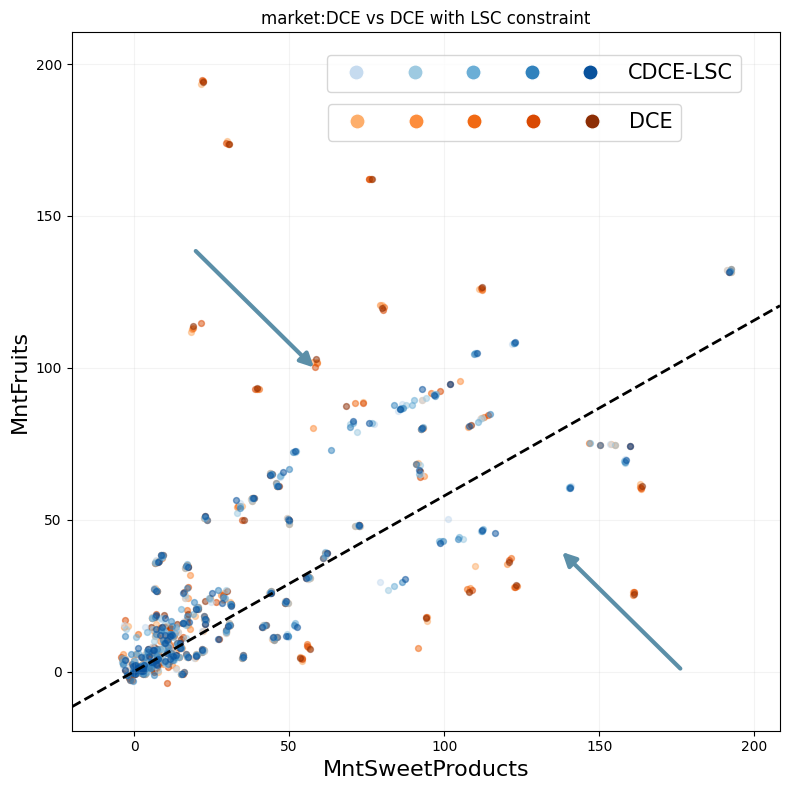

In [6]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

file_path_dce = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")
file_path_lsc = os.path.join(data_dir, f"{dataset_name}_LSCConstraint.xlsx")

xl_dce = pd.ExcelFile(file_path_dce, engine="openpyxl")
xl_lsc = pd.ExcelFile(file_path_lsc, engine="openpyxl")

target_sheets_dce = xl_dce.sheet_names[:5]
target_sheets_lsc = xl_lsc.sheet_names[:5]

color_list_dce = ["#fdae6b", "#fd8d3c", "#f16913", "#d94801", "#8c2d04"]
color_list_lsc = ["#c6dbef", "#9ecae1", "#6baed6", "#3182bd", "#08519c"]

fig, ax = plt.subplots(figsize=(8, 8))

all_x = []
all_y = []

# DCE: orange
for i, sheet in enumerate(target_sheets_dce):
    df = pd.read_excel(file_path_dce, sheet_name=sheet, engine="openpyxl")
    x_col = "MntSweetProducts"
    y_col = "MntFruits"

    df_clean = df[[x_col, y_col]].dropna()
    x = df_clean[x_col].to_numpy()
    y = df_clean[y_col].to_numpy()

    all_x.append(x)
    all_y.append(y)

    ax.scatter(
        x, y,
        s=18,
        alpha=0.50,
        color=color_list_dce[i],
        label=sheet.replace("DCE_", "DCE ")
    )

# LSC: blue
for i, sheet in enumerate(target_sheets_lsc):
    df = pd.read_excel(file_path_lsc, sheet_name=sheet, engine="openpyxl")
    x_col = "MntSweetProducts"
    y_col = "MntFruits"

    df_clean = df[[x_col, y_col]].dropna()
    x = df_clean[x_col].to_numpy()
    y = df_clean[y_col].to_numpy()

    all_x.append(x)
    all_y.append(y)

    ax.scatter(
        x, y,
        s=18,
        alpha=0.50,
        color=color_list_lsc[i],
        label=sheet.replace("LSC_", "LSC ")
    )

all_x = np.concatenate(all_x)
all_y = np.concatenate(all_y)

x_min, x_max = all_x.min(), all_x.max()
y_min, y_max = all_y.min(), all_y.max()

x_range = x_max - x_min
y_range = y_max - y_min

x_left = x_min - 0.08 * x_range
x_right = x_max + 0.08 * x_range
y_low = y_min - 0.08 * y_range
y_high = y_max + 0.08 * y_range

ax.set_xlim(x_left, x_right)
ax.set_ylim(y_low, y_high)

line_x = np.linspace(x_left, x_right, 300)
line_y = 0.5785 * line_x + 0.0000
ax.plot(
    line_x,
    line_y,
    linestyle="--",
    linewidth=2,
    color="black"
)

ax.set_xlabel("MntSweetProducts", fontsize=16)
ax.set_ylabel("MntFruits", fontsize=16)
ax.set_title(f"{dataset_name}:DCE vs DCE with LSC constraint")
ax.grid(alpha=0.15)
# ax.legend(frameon=True, loc="lower right", fontsize=9)

h1 = [Line2D([],[], marker='o', color='w', markerfacecolor=c, markersize=11) for c in color_list_lsc]
leg1 = plt.legend(
    handles=h1, 
    labels=["","","","","CDCE-LSC"], 
    loc="lower right", 
    bbox_to_anchor=(0.96, 0.9), 
    ncol=5, 
    frameon=True, 
    fontsize=15,
    columnspacing=0.01  # 
)
plt.gca().add_artist(leg1)

h2 = [
    Line2D([], [], marker='o', color='w', markerfacecolor=c, markersize=11)
    for c in color_list_dce
]
leg2 = plt.legend(
    handles=h2, 
    labels=["","","","","DCE"], 
    loc="lower right", 
    bbox_to_anchor=(0.875, 0.83),   
    ncol=5, 
    frameon=True, 
    fontsize=15,
    columnspacing=0.01
)

ax.annotate(
    "",
    xy=(x_left + 0.4 * x_range, y_low + 0.6 * y_range),
    xytext=(x_left + 0.2 * x_range, y_low + 0.8 * y_range),
    arrowprops=dict(
        arrowstyle="-|>",     
        linewidth=3,          
        color="#5B8FA8",      
        mutation_scale=20     
    )
)

ax.annotate(
    "",
    xy=(x_left + 0.8 * x_range, y_low + 0.3* y_range),
    xytext=(x_left + 1 * x_range, y_low + 0.1 * y_range),
    arrowprops=dict(
        arrowstyle="-|>",     
        linewidth=3,          
        color="#5B8FA8",      
        mutation_scale=20     
    )
)

plt.tight_layout()
plt.show()

# fsd

In [4]:
from explainers.constraints.FSDConstraint import FSDConstraintTorch
import numpy as np
X_fact= pd.read_csv(os.path.join("market",'market_explained_samples.csv'))
# X_cf= pd.read_csv("cardio_counterfactual.csv")  # 注释掉：改为读取Excel Sheet

file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []

for sheet_name in target_sheets:
        
    X_cf = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")
    
    fact_NumDealsPurchases  = X_fact["NumDealsPurchases"]
    cf_NumDealsPurchases = X_cf["NumDealsPurchases"]

    result_cf = FSDConstraintTorch.check_FSD(
        fact_NumDealsPurchases , cf_NumDealsPurchases ,
        direction=1   
    )   
    result_list.append({
        "Sheet_Name": sheet_name,
        "Violation_Count": len(result_cf["violations"])
    })

result_df = pd.DataFrame(result_list)
print("\n=== Result DataFrame (Sheet Name & Violation Count) ===")
print(result_df)

violation_counts = result_df["Violation_Count"]
mean_violation = np.mean(violation_counts)  
std_violation = np.std(violation_counts, ddof=1)  

print("\n=== Overall Statistics of Violation Count ===")
print(f"Mean of 5 Sheet Violation Counts : {mean_violation:.6f}")
print(f"Std of 5 Sheet Violation Counts : {std_violation:.6f}")


=== Result DataFrame (Sheet Name & Violation Count) ===
    Sheet_Name  Violation_Count
0  DCE_Seed_40               44
1  DCE_Seed_41               38
2  DCE_Seed_42               48
3  DCE_Seed_43               37
4  DCE_Seed_44               40

=== Overall Statistics of Violation Count ===
Mean of 5 Sheet Violation Counts : 41.400000
Std of 5 Sheet Violation Counts : 4.560702


In [5]:
from explainers.constraints.FSDConstraint import FSDConstraintTorch

X_fact= pd.read_csv(os.path.join("market",'market_explained_samples.csv'))

file_path = os.path.join(data_dir, f"{dataset_name}_FSDConstraint_NumDealsPurchases_0.004.xlsx")

xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

result_list = []

for sheet_name in target_sheets:
        
    X_cf = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")
    
    fact_NumDealsPurchases = X_fact["NumDealsPurchases"]
    cf_NumDealsPurchases = X_cf["NumDealsPurchases"]

    result_cf = FSDConstraintTorch.check_FSD(
        fact_NumDealsPurchases, cf_NumDealsPurchases,
        direction=1   
    )   
    result_list.append({
        "Sheet_Name": sheet_name,
        "Violation_Count": len(result_cf["violations"])
    })

result_df = pd.DataFrame(result_list)
print("\n=== Result DataFrame (Sheet Name & Violation Count) ===")
print(result_df)

violation_counts = result_df["Violation_Count"]
mean_violation = np.mean(violation_counts)  
std_violation = np.std(violation_counts, ddof=1)  

print("\n=== Overall Statistics of Violation Count ===")
print(f"Mean of 5 Sheet Violation Counts : {mean_violation:.6f}")
print(f"Std of 5 Sheet Violation Counts : {std_violation:.6f}")



=== Result DataFrame (Sheet Name & Violation Count) ===
    Sheet_Name  Violation_Count
0  FSD_Seed_40                8
1  FSD_Seed_41                8
2  FSD_Seed_42               13
3  FSD_Seed_43                8
4  FSD_Seed_44               11

=== Overall Statistics of Violation Count ===
Mean of 5 Sheet Violation Counts : 9.600000
Std of 5 Sheet Violation Counts : 2.302173


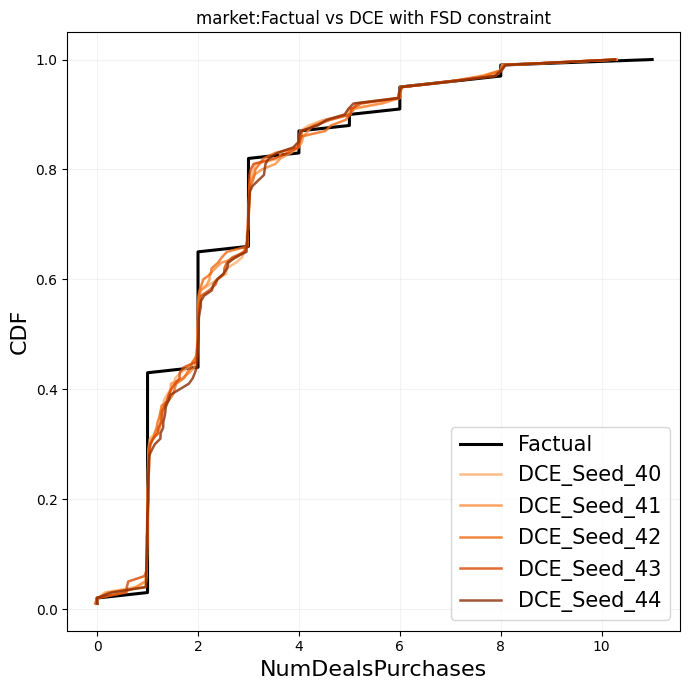

In [6]:
import matplotlib.pyplot as plt
X_fact= pd.read_csv(os.path.join("market",'market_explained_samples.csv'))

fact_weight = X_fact["NumDealsPurchases"].dropna().to_numpy()
fact_weight_sorted = np.sort(fact_weight)
fact_cdf = np.arange(1, len(fact_weight_sorted) + 1) / len(fact_weight_sorted)

file_path = os.path.join(data_dir, f"{dataset_name}_DCE.xlsx")
xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

orange_colors = ["#fdae6b", "#fd8d3c", "#f16913", "#d94801", "#8c2d04"]

plt.figure(figsize=(7, 7))

plt.plot(
    fact_weight_sorted,
    fact_cdf,
    color="black",
    linewidth=2.2,
    label="Factual"
)

for i, sheet_name in enumerate(target_sheets):
    X_cf = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")
    cf_weight = X_cf["NumDealsPurchases"].dropna().to_numpy()
    cf_weight_sorted = np.sort(cf_weight)
    cf_cdf = np.arange(1, len(cf_weight_sorted) + 1) / len(cf_weight_sorted)

    seed_label = sheet_name
    plt.plot(
        cf_weight_sorted,
        cf_cdf,
        color=orange_colors[i],
        linewidth=1.8,
        alpha=0.8,
        label=seed_label
    )

plt.xlabel("NumDealsPurchases", fontsize=16)
plt.ylabel("CDF", fontsize=16)
plt.title(f"{dataset_name}:Factual vs DCE with FSD constraint")
plt.grid(alpha=0.15)
plt.legend(frameon=True,loc="lower right", fontsize=15)
plt.tight_layout()
plt.show()

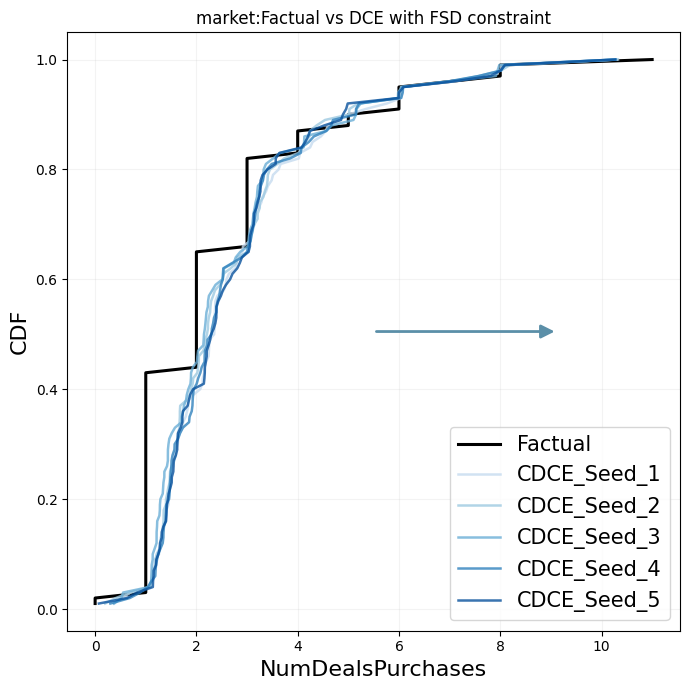

In [8]:
X_fact= pd.read_csv(os.path.join("market",'market_explained_samples.csv'))

fact_weight = X_fact["NumDealsPurchases"].dropna().to_numpy()
fact_weight_sorted = np.sort(fact_weight)
fact_cdf = np.arange(1, len(fact_weight_sorted) + 1) / len(fact_weight_sorted)

file_path = os.path.join(data_dir, f"{dataset_name}_FSDConstraint_NumDealsPurchases_0.004.xlsx")
xl = pd.ExcelFile(file_path, engine="openpyxl")
target_sheets = xl.sheet_names[:5]

blue_colors = ["#c6dbef", "#9ecae1", "#6baed6", "#3182bd", "#08519c"]

plt.figure(figsize=(7, 7))

plt.plot(
    fact_weight_sorted,
    fact_cdf,
    color="black",
    linewidth=2.2,
    label="Factual"
)

for i, sheet_name in enumerate(target_sheets):
    X_cf = pd.read_excel(file_path, sheet_name=sheet_name, engine="openpyxl")
    cf_weight = X_cf["NumDealsPurchases"].dropna().to_numpy()
    cf_weight_sorted = np.sort(cf_weight)
    cf_cdf = np.arange(1, len(cf_weight_sorted) + 1) / len(cf_weight_sorted)

    plt.plot(
        cf_weight_sorted,
        cf_cdf,
        color=blue_colors[i],
        linewidth=1.8,
        alpha=0.8,
        label=f"CDCE_Seed_{i + 1}" 
    )

ax = plt.gca()

ax.annotate(
    '',
    xy=(0.8, 0.5),      
    xytext=(0.5, 0.5),  
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(
        arrowstyle='-|>',
        linewidth=6,
        mutation_scale=20,
        color="#5B8FA8",
        lw=2
    )
)


plt.xlabel("NumDealsPurchases", fontsize=16)
plt.ylabel("CDF", fontsize=16)
plt.title(f"{dataset_name}:Factual vs DCE with FSD constraint")
plt.grid(alpha=0.15)
plt.legend(frameon=True,loc="lower right", fontsize=15)
plt.tight_layout()
plt.show()